In [1]:
from src.object_funcs import no_object, object_two_absorbing_bars
from src.imaging_systems import Michaelson
from src.simulations import SPDC
from src.simulations import Imaging
from src.plotting_helpers import plot_visibility,analyze_psf, plot_vertical_visibility_profile
from src.resolution_estimation import rayleigh_like_two_bar_metric

import numpy as np
from tqdm.auto import tqdm

In [2]:
# Parameters - nominal values are actually used in the experiment
# - crystal length
L_nominal = 2e-3 # m

# - crystal temperature
t_nominal = 25 # deg C

# - pump beam waist
omega_0_nominal = 750e-6 # m

# - pump power
P = 0.5 # W

# - ppKTP period
period = 9.325e-6 # m

# - pump wavelength
lambda_p = 532e-9 # m
lambda_s_degenerate = 1064e-9 #m

# - central signal wavelength
lambda_s_collinear = 873.76e-9

# - signal angles to be considered (this range covers entire detector plane)
theta_s_min=0.0
theta_s_max=0.025

# Object
object_func = no_object

# Detector
detector_pixels = 5001
detector_size = 3e-3

In [3]:
lambda_s_min = lambda_s_collinear - 25e-9
lambda_s_max = lambda_s_collinear + 10e-9

spdc = SPDC(
    L=L_nominal,
    t=t_nominal,
    period=period,
    m=-1,
    chi_eff=6e-12,
    lambda_p=lambda_p,
    P=P,
    omega_0=omega_0_nominal,
    T_I=0,
    lambda_s_min=lambda_s_min,
    lambda_s_max=lambda_s_max,
    theta_s_min=theta_s_min,
    theta_s_max=theta_s_max,
    grid_size=201,
    N_phi=256,
    min_N_i=128,
    max_N_i=512,
    n_processes=9,
    signal_batch_size=32,
    seed=0,
)

imaging_system = Michaelson(source=spdc, f_i=0.2, f_d=0.15)

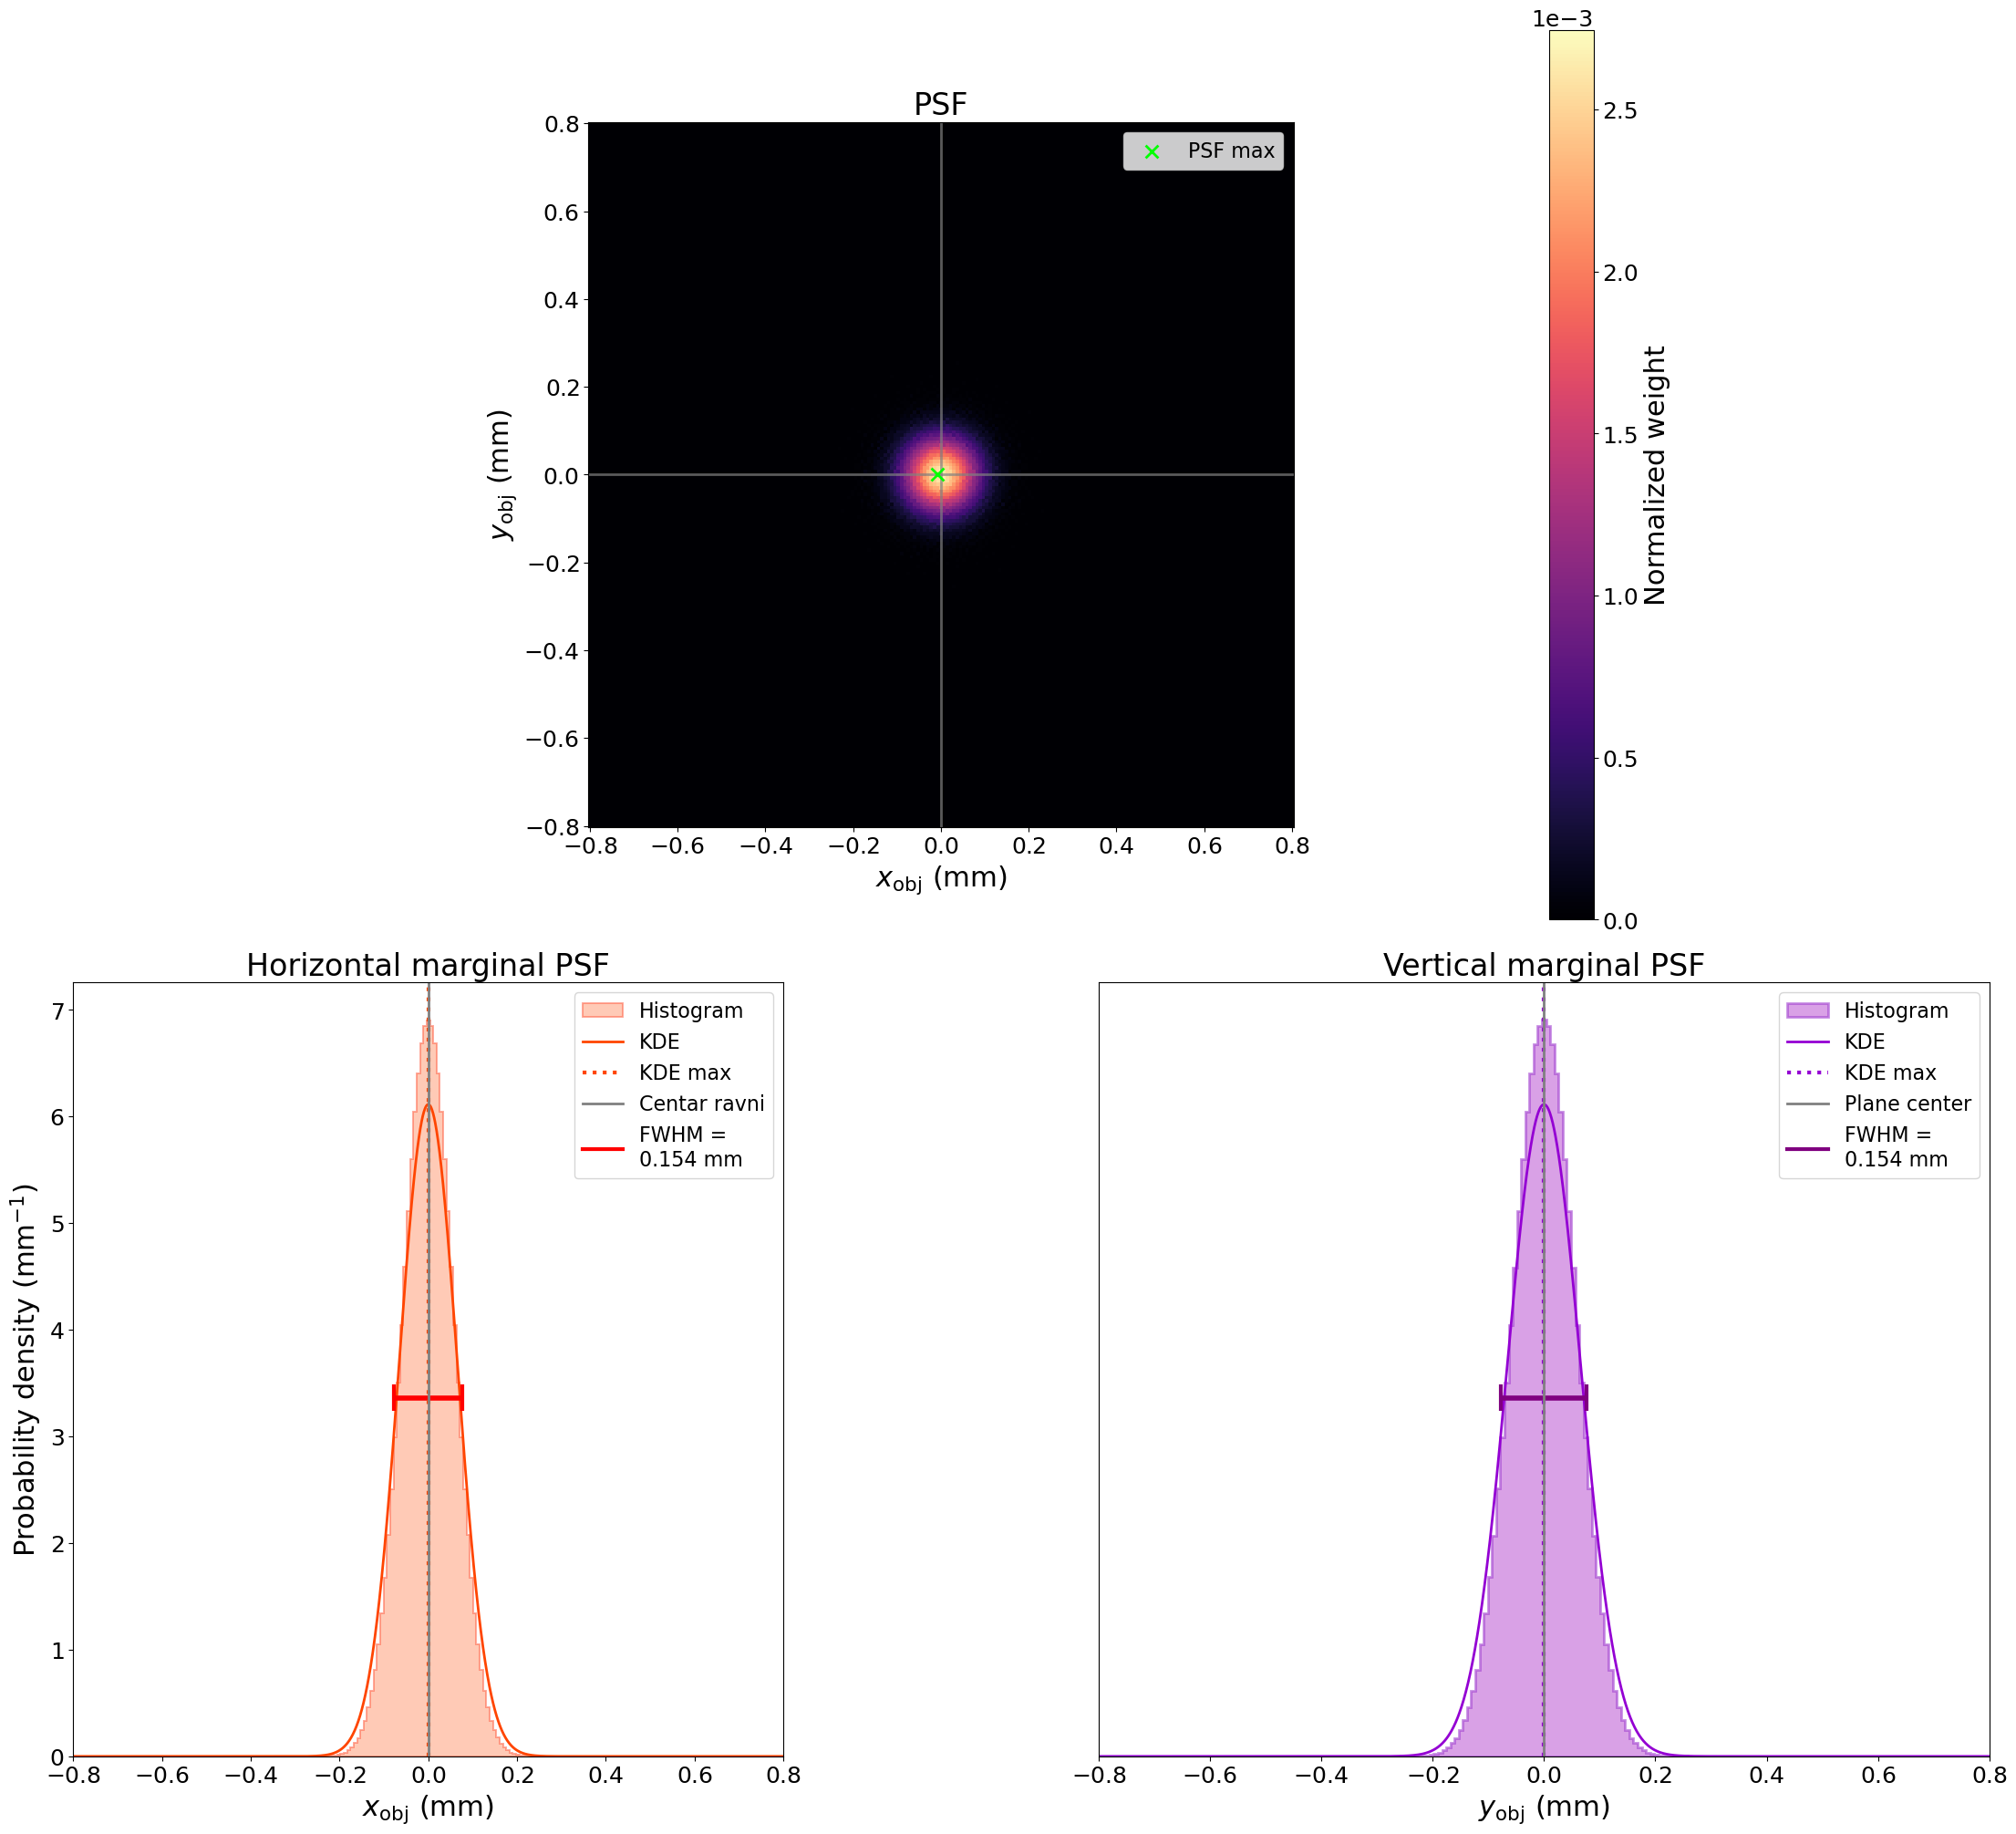

Initial resolution estimate: 0.1536646525218878mm


In [4]:
# Analyze kernel
object_func = no_object

imaging = Imaging(
    source=spdc,
    imaging_system=imaging_system,
    detector_size=detector_size,
    detector_pixels=detector_pixels,
    object_func=object_func,
    object_plane_pixels=5001,
    signal_batch_size=32,
    n_processes=9,
    seed=0,
)

kernel = imaging.get_kernel()

# Get initial system resolution estimate from FWHM of system PSF
res_estimate = analyze_psf(
    psf=kernel,
    object_x_edges=imaging.object_x_edges,
    object_y_edges=imaging.object_y_edges,
    display_size=1.6e-3,
    normalize=True,
    normalize_display=True
)
print (f"Initial resolution estimate: {res_estimate*1e3}mm")

In [6]:
# Determine system resolution using two absorbing bar object and Rayleigh-like criterion
criterion = 73.5
bar_width = 2e-3
gaps = np.linspace(
    0.5 * res_estimate,
    1.5 * res_estimate,
    11,
)
metric_values = []
resolved_values = []
for gap in tqdm(gaps):
    object_func = lambda x, y: object_two_absorbing_bars(x, y, bar_width=bar_width, gap=gap, center_y=0.0)

    visibility_object, details = (
    imaging.convolve_on_extended_object_plane(
        object_func=object_func,
        kernel=kernel,
        extension_factor=2,
        t_i=1.0,
        )
    )

    visibility_detector = (
        imaging.project_object_visibility_to_detector(
            visibility_object,
            magnification=imaging_system.magnification(),
        )
    )

    separation = gap + bar_width
    metric_value, resolved = rayleigh_like_two_bar_metric(
            visibility=visibility_object,
            x_centers=imaging.object_x_centers,
            y_centers=imaging.object_y_centers,
            bar_width=bar_width,
            separation=separation,
            center_y=0.0,
    )
    print(metric_value)
    print(gap)
    print("---------------------------------")
    metric_values.append(metric_value)
    resolved_values.append(resolved)

gaps = np.asarray(gaps, dtype=float)
metric_values = np.asarray(metric_values, dtype=float)
resolved_values = np.asarray(resolved_values, dtype=bool)

resolved_indices = np.flatnonzero(resolved_values)
if resolved_indices.size == 0:
    print("No resolved gap was found in the scanned range.")
    print("Increase the largest tested gap.")
else:
    first_resolved_index = resolved_indices[0]
    resolution_gap = gaps[first_resolved_index]
    resolution_metric = metric_values[first_resolved_index]
    print(f"Estimated resolution gap: {resolution_gap * 1e3:.5f} mm")
    print(f"Metric at this gap: {resolution_metric:.5f}")

  0%|          | 0/11 [00:00<?, ?it/s]

0.4815368916647489
7.683232626094389e-05
---------------------------------
0.5615845018450161
9.219879151313267e-05
---------------------------------
0.6340332340884134
0.00010756525676532145
---------------------------------
0.6984863597978067
0.00012293172201751024
---------------------------------
0.7548828439136859
0.000138298187269699
---------------------------------
0.8034363096216454
0.00015366465252188778
---------------------------------
0.844574003117185
0.00016903111777407656
---------------------------------
0.8787842058669019
0.00018439758302626536
---------------------------------
0.906799339941471
0.00019976404827845413
---------------------------------
0.9294128624933762
0.0002151305135306429
---------------------------------
0.9472961604143056
0.00023049697878283168
---------------------------------
Estimated resolution gap: 0.13830 mm
Metric at this gap: 0.75488


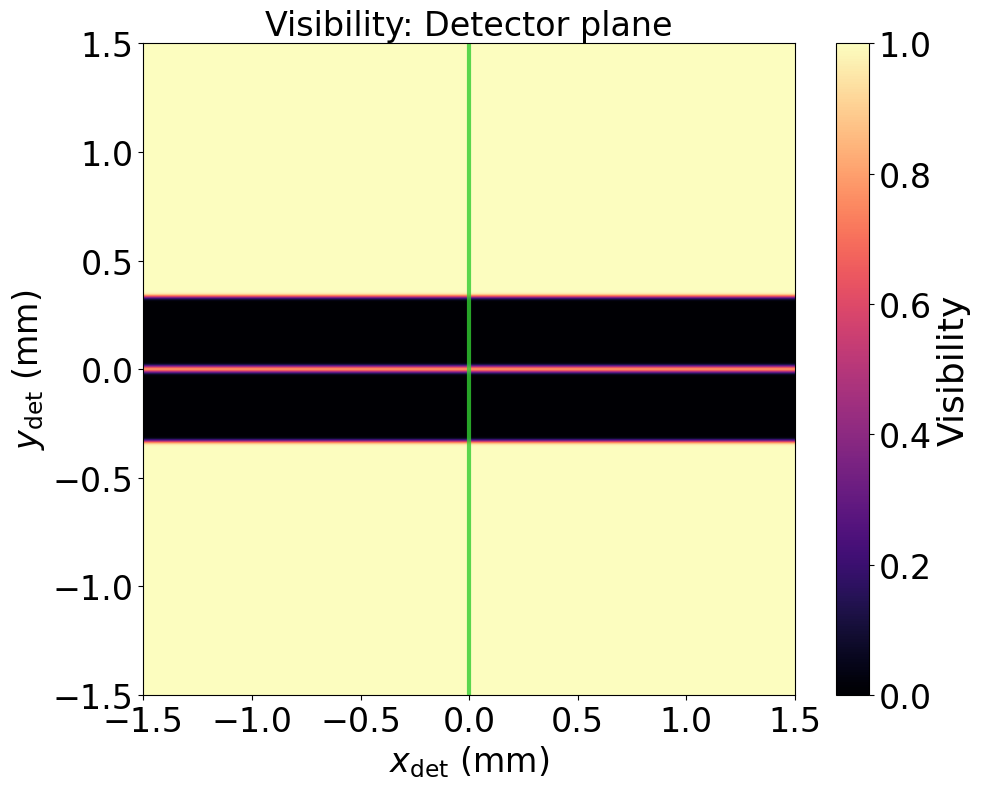

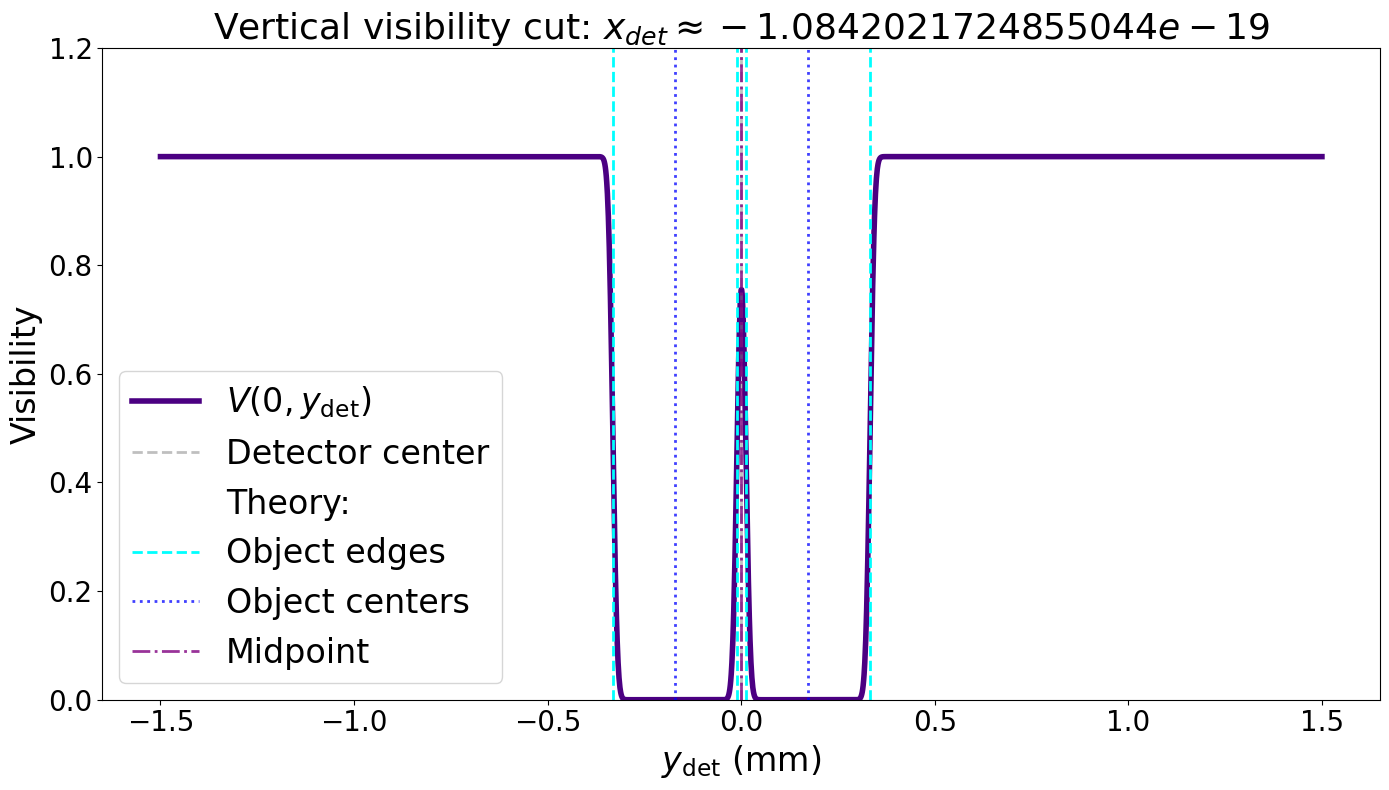

In [7]:
object_func = lambda x, y: object_two_absorbing_bars(x, y, bar_width=bar_width, gap=resolution_gap, center_y=0.0)

visibility_object, details = (
imaging.convolve_on_extended_object_plane(
    object_func=object_func,
    kernel=kernel,
    extension_factor=2,
    t_i=1.0,
    )
)

visibility_detector = (
    imaging.project_object_visibility_to_detector(
        visibility_object,
        magnification=imaging_system.magnification(),
    )
)

np.save("visibility_at_limit.npy", visibility_detector)
plot_visibility(detector_size, detector_pixels, visibility_detector, magnification=imaging_system.magnification(), overlay_object_contour=False, object_func=object_func, draw_x0=True, filename="visibility_at_limit.png")

expected_separation = resolution_gap + bar_width
profile_result = plot_vertical_visibility_profile(
    detector_visibility=visibility_detector,
    detector_size=imaging.detector_size,
    detector_pixels=detector_pixels,
    expected_bar_width=2e-3,
    expected_separation=expected_separation,
    center_y=0.0,
    magnification=imaging_system.magnification(),
    prominence=0.02,
    unit="mm",
    filename="visibility_at_limit_profile.pdf",
)